# Standalone BESS Scenario (10 MW)

This notebook evaluates a standalone battery energy storage system (BESS) with fixed annual revenue and standard cost assumptions.

**Assumptions**
- Annual revenue: EUR 150,000 per MW (real, year-1)
- BESS power: 10 MW
- Duration: 2 h (20 MWh at 10 MW)
- Project lifetime: 30 years
- Replacement cost: 30% of initial CAPEX
- Replacement schedule: two replacements over the project life


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '../src')

# Clear cached modules to reload updated config values
for mod_name in ['economics', 'config']:
    if mod_name in sys.modules:
        del sys.modules[mod_name]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (
    CAPEX_BESS_EUR_PER_KWH,
    OPEX_BESS_EUR_PER_KW_PER_YEAR,
    LIFETIME_BESS_YEARS,
    BESS_REPLACEMENT_COST_FRACTION,
    PROJECT_LIFETIME_YEARS,
    WACC_BESS_REAL,
    STANDALONE_BESS_ANNUAL_REVENUE_EUR_PER_MW,
    STANDALONE_BESS_POWER_MW,
)
from economics import npv, irr


ImportError: cannot import name 'BESS_REPLACEMENT_COST_FRACTION' from 'config' (/Users/fynnfroehlich/Master Thesis/notebooks/../src/config.py)

In [ ]:
# Scenario assumptions
bess_duration_h = 2.0
bess_power_mw = STANDALONE_BESS_POWER_MW
bess_energy_mwh = bess_power_mw * bess_duration_h
annual_revenue_eur = STANDALONE_BESS_ANNUAL_REVENUE_EUR_PER_MW * bess_power_mw

bess_capex_eur = bess_energy_mwh * 1000.0 * CAPEX_BESS_EUR_PER_KWH
bess_opex_eur_per_year = bess_power_mw * 1000.0 * OPEX_BESS_EUR_PER_KW_PER_YEAR
replacement_cost_eur = bess_capex_eur * BESS_REPLACEMENT_COST_FRACTION

project_lifetime_years = PROJECT_LIFETIME_YEARS
bess_lifetime_years = LIFETIME_BESS_YEARS

# Excludes replacement at project end (no remaining life).
replacement_years = [
    year
    for year in range(bess_lifetime_years, project_lifetime_years, bess_lifetime_years)
]
replacement_years


[15]

In [ ]:
# Build cash flows (year 0 CAPEX + annual net cash flows)
cash_flows = np.zeros(project_lifetime_years + 1)
cash_flows[0] = -bess_capex_eur

for year in range(1, project_lifetime_years + 1):
    cash_flows[year] = annual_revenue_eur - bess_opex_eur_per_year
    if year in replacement_years:
        cash_flows[year] -= replacement_cost_eur

npv_eur = npv(cash_flows, WACC_BESS_REAL)
try:
    irr_value = irr(cash_flows)
except ValueError:
    irr_value = np.nan

cum_cash_flow = cash_flows.cumsum()
payback_year = int(np.argmax(cum_cash_flow >= 0)) if np.any(cum_cash_flow >= 0) else None

npv_eur, irr_value, payback_year


(np.float64(25293794.309075058), 0.20416751591232257, 5)

In [ ]:
summary = pd.DataFrame(
    [
        ("BESS power (MW)", bess_power_mw),
        ("BESS energy (MWh)", bess_energy_mwh),
        ("Annual revenue (EUR)", annual_revenue_eur),
        ("Annual revenue per MW (EUR/MW)", STANDALONE_BESS_ANNUAL_REVENUE_EUR_PER_MW),
        ("Annual OPEX (EUR)", bess_opex_eur_per_year),
        ("Initial CAPEX (EUR)", bess_capex_eur),
        ("Replacement cost (EUR)", replacement_cost_eur),
        ("Replacement years", ', '.join(str(y) for y in replacement_years)),
        ("Discount rate (real)", WACC_BESS_REAL),
        ("NPV (EUR)", npv_eur),
        ("IRR", irr_value),
        ("Payback year", payback_year if payback_year is not None else 'No payback'),
    ],
    columns=["Metric", "Value"],
)
summary


,Metric,Value
0,BESS power (MW),10.0
1,BESS energy (MWh),20.0
2,Annual revenue (EUR),1722872.1
3,Annual revenue per MW (EUR/MW),172287.21
4,Annual OPEX (EUR),53000.0
5,Initial CAPEX (EUR),8000000.0
6,Replacement cost (EUR),2400000.0
7,Replacement years,15
8,Discount rate (real),0.025
9,NPV (EUR),25293794.309075


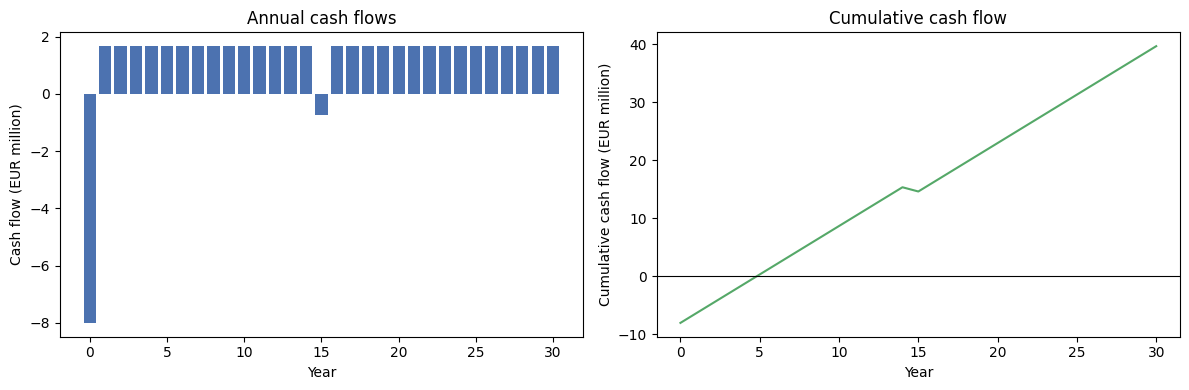

In [ ]:
years = np.arange(0, project_lifetime_years + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(years, cash_flows / 1e6, color='#4C72B0')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Cash flow (EUR million)')
axes[0].set_title('Annual cash flows')

axes[1].plot(years, cum_cash_flow / 1e6, color='#55A868')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Cumulative cash flow (EUR million)')
axes[1].set_title('Cumulative cash flow')

plt.tight_layout()
plt.show()


,Metric,Monthly avg (EUR/kW),Annualized (EUR/kW-year)
0,Day-Ahead charge,-0.403333,-4.84
1,Day-Ahead discharge,3.976667,47.72
2,Intraday charge,-3.788333,-45.46
3,Intraday discharge,5.835833,70.03
4,aFRR energy charge,-0.170000,-2.04
5,aFRR energy discharge,3.470000,41.64
6,FCR gross margin,0.635833,7.63
7,aFRR capacity margin,4.163333,49.96
8,Total gross margin,13.719167,164.63


,Market,Monthly avg (EUR/kW),Share of total (%)
0,Day-Ahead net,3.573333,26.046286
1,Intraday net,2.047500,14.924376
2,aFRR energy net,3.300000,24.053939
3,FCR margin,0.635833,4.634635
4,aFRR capacity margin,4.163333,30.346838


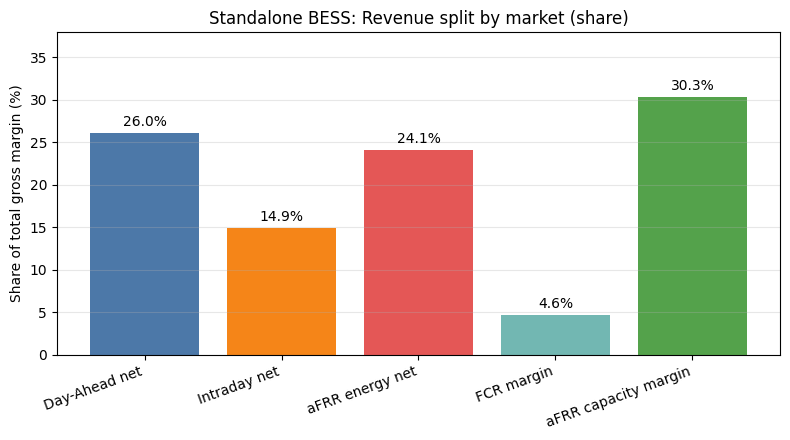

In [ ]:
# Revenue split (from monthly gross margin table)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Monthly values in EUR/kW (Jan-Dec 2024)
rows = [
    [-0.14, 1.88, -3.32, 4.69, -0.51, 3.23, 0.60, 2.48, 8.90],
    [-0.06, 1.38, -2.55, 4.26, -0.71, 2.80, 0.14, 1.17, 6.43],
    [-0.09, 2.01, -2.94, 6.26, 0.14, 3.39, 0.10, 0.82, 9.69],
    [0.13, 2.86, -2.01, 4.92, 0.78, 3.75, 0.79, 3.83, 15.04],
    [0.32, 3.75, -2.83, 3.77, 1.15, 3.63, 1.08, 5.79, 16.68],
    [-0.61, 3.89, -2.76, 6.16, -0.12, 4.35, 1.37, 9.60, 21.88],
    [-0.46, 5.72, -3.94, 4.79, 0.19, 3.95, 1.05, 5.44, 16.75],
    [-0.45, 6.58, -3.77, 6.41, 0.15, 3.87, 0.67, 5.16, 18.61],
    [-0.43, 5.41, -2.98, 5.51, 0.01, 4.04, 0.64, 5.49, 17.68],
    [-0.43, 3.71, -4.88, 8.07, -0.46, 3.26, 0.35, 3.57, 13.20],
    [-1.40, 5.77, -6.91, 7.42, -1.51, 3.00, 0.32, 2.99, 9.67],
    [-1.22, 4.76, -6.57, 7.77, -1.15, 2.37, 0.52, 3.62, 10.10],
]

col_names = [
    'Day-Ahead charge',
    'Day-Ahead discharge',
    'Intraday charge',
    'Intraday discharge',
    'aFRR energy charge',
    'aFRR energy discharge',
    'FCR gross margin',
    'aFRR capacity margin',
    'Total gross margin',
]

arr = np.array(rows, dtype=float)
monthly_means = arr.mean(axis=0)
annual_means = monthly_means * 12.0

# Net contribution by market (charge + discharge)
net_da = arr[:, 0] + arr[:, 1]
net_id = arr[:, 2] + arr[:, 3]
net_afrr = arr[:, 4] + arr[:, 5]
net_components = np.array([
    net_da.mean(),
    net_id.mean(),
    net_afrr.mean(),
    arr[:, 6].mean(),
    arr[:, 7].mean(),
])
net_labels = [
    'Day-Ahead net',
    'Intraday net',
    'aFRR energy net',
    'FCR margin',
    'aFRR capacity margin',
]
total_mean = arr[:, 8].mean()
net_share_pct = (net_components / total_mean) * 100.0

summary_df = pd.DataFrame({
    'Metric': col_names,
    'Monthly avg (EUR/kW)': monthly_means,
    'Annualized (EUR/kW-year)': annual_means,
})
display(summary_df)

split_df = pd.DataFrame({
    'Market': net_labels,
    'Monthly avg (EUR/kW)': net_components,
    'Share of total (%)': net_share_pct,
})
display(split_df)

# Bar chart of net contributions (monthly avg)
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(net_labels, net_share_pct, color=['#4C78A8', '#F58518', '#E45756', '#72B7B2', '#54A24B'])
ax.set_ylabel('Share of total gross margin (%)')
ax.set_title('Standalone BESS: Revenue split by market (share)')
ax.set_ylim(0, max(net_share_pct) * 1.25)
ax.grid(True, axis='y', alpha=0.3)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
